# DOCUMENT RETRIEVAL MODULE — BM25-Okapi (Best Method)
**Bài Tập Lớn NLP Summer 2026** — Chủ đề 7: Question Answering System (Hỏi - Đáp Tiếng Việt)

Notebook này triển khai **Document Retrieval** sử dụng phương pháp **BM25-Okapi** — phương pháp đạt kết quả tốt nhất trong benchmark so sánh 3 phương pháp:

| Method | MRR | Recall@5 | Recall@10 | Recall@50 |
|--------|-----|----------|-----------|----------|
| TF-IDF (DrQA) | 0.652 | 76.5% | 83.2% | 94.1% |
| **BM25-Okapi** 🏆 | **0.685** | **79.5%** | **85.2%** | **93.7%** |
| Dense (vi-sbert) | 0.423 | 54.0% | 63.7% | 81.3% |

### Pipeline:
1. **Load Corpus** đã chuẩn hóa từ `data/processed/corpus_clean.parquet`
2. **Tokenize** văn bản tiếng Việt bằng `pyvi` (word segmentation)
3. **Build BM25 Index** (Okapi BM25, k1=1.5, b=0.75)
4. **Retrieval Demo** — Truy vấn mẫu với câu hỏi tiếng Việt
5. **Đánh giá Recall@k & MRR** trên tập Dev và Test (UIT-ViQuAD2.0)
6. **Trực quan hóa** kết quả & phân tích lỗi

## 1. Import Thư Viện & Cấu Hình

In [1]:
import os
import sys
import time
import json
import pickle
import unicodedata
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Encoding cho Windows
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

# Auto-install dependencies
try:
    import rank_bm25
    from pyvi import ViTokenizer
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rank-bm25', 'pyvi', '-q'])
    import rank_bm25
    from pyvi import ViTokenizer

# Paths
BASE_DIR = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
DATA_DIR = BASE_DIR / 'data' / 'processed'
INDEX_DIR = BASE_DIR / 'data' / 'indexes'
RESULTS_DIR = BASE_DIR / 'results'

INDEX_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'[+] Base Directory : {BASE_DIR}')
print(f'[+] Data Directory : {DATA_DIR}')
print(f'[+] Index Directory: {INDEX_DIR}')

[+] Base Directory : C:\New folder\Code\QA_system
[+] Data Directory : C:\New folder\Code\QA_system\data\processed
[+] Index Directory: C:\New folder\Code\QA_system\data\indexes


## 2. Load Corpus & Dữ Liệu QA

In [2]:
# ── Load Corpus ──
corpus_df = pd.read_parquet(DATA_DIR / 'corpus_clean.parquet')
print(f'[+] Corpus: {len(corpus_df)} documents')
print(f'    Columns: {list(corpus_df.columns)}')
print(f'    Memory: {corpus_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# ── Load QA datasets ──
dev_df = pd.read_parquet(DATA_DIR / 'viquad_dev_clean.parquet')
test_df = pd.read_parquet(DATA_DIR / 'viquad_test_clean.parquet')

print(f'\n[+] Dev set : {len(dev_df)} questions')
print(f'[+] Test set: {len(test_df)} questions')

# Preview corpus
print('\n' + '='*70)
print('PREVIEW CORPUS (5 mẫu đầu tiên)')
print('='*70)
for i in range(min(5, len(corpus_df))):
    row = corpus_df.iloc[i]
    print(f"\n--- Doc #{i+1} [ID: {row['id']}] ---")
    print(f"Title: {row['title']}")
    print(f"Text : {str(row['text'])[:150]}...")

[+] Corpus: 5317 documents
    Columns: ['id', 'title', 'text']
    Memory: 9.4 MB



[+] Dev set : 3814 questions
[+] Test set: 7301 questions

PREVIEW CORPUS (5 mẫu đầu tiên)

--- Doc #1 [ID: doc_00001] ---
Title: Phạm Văn Đồng
Text : Phạm Văn Đồng (1 tháng 3 năm 1906 – 29 tháng 4 năm 2000) là Thủ tướng đầu tiên của nước Cộng hòa Xã hội chủ nghĩa Việt Nam từ năm 1976 (từ năm 1981 gọ...

--- Doc #2 [ID: doc_00002] ---
Title: Phạm Văn Đồng
Text : Năm 1954, ông được giao nhiệm vụ Trưởng phái đoàn Chính phủ dự Hội nghị Genève về Đông Dương. Những đóng góp của đoàn Việt Nam do ông đứng đầu là vô c...

--- Doc #3 [ID: doc_00003] ---
Title: Phạm Văn Đồng
Text : Phạm Văn Đồng có vợ là bà Phạm Thị Cúc và một người con trai duy nhất tên là Phạm Sơn Dương, hiện là thiếu tướng Quân đội Nhân dân Việt Nam, phó giám ...

--- Doc #4 [ID: doc_00004] ---
Title: Phạm Văn Đồng
Text : Ông Việt Phương, nguyên thư ký của Thủ tướng Phạm Văn Đồng, trong buổi họp báo giới thiệu sách của các nhà ngoại giao, đã tiết lộ rằng khi đàm phán hi...

--- Doc #5 [ID: doc_00005] ---
Title: Phạm Văn Đồng

## 3. Vietnamese Tokenizer (pyvi Word Segmentation)

Tiếng Việt là ngôn ngữ đơn lập (isolating language), trong đó từ ghép gồm nhiều âm tiết:
- "Hà Nội" → `Hà_Nội` (1 token)
- "sinh viên" → `sinh_viên` (1 token)

Việc tách từ ghép (word segmentation) cải thiện đáng kể chất lượng retrieval
vì BM25 sẽ match chính xác từ thay vì match từng âm tiết rời rạc.

In [3]:
def tokenize_vi(text: str) -> list:
    """Tokenize tiếng Việt bằng pyvi → list of lowercased tokens."""
    segmented = ViTokenizer.tokenize(str(text))
    return [t.lower() for t in segmented.split()]

# Demo tokenizer
demo_sentences = [
    "Hà Nội là thủ đô của Việt Nam",
    "Đại học Bách Khoa thành phố Hồ Chí Minh",
    "Nguyễn Du là tác giả của Truyện Kiều",
]

print('='*70)
print('DEMO VIETNAMESE WORD SEGMENTATION (pyvi)')
print('='*70)
for sent in demo_sentences:
    tokens = tokenize_vi(sent)
    print(f'\nInput : {sent}')
    print(f'Tokens: {tokens}')
    print(f'Count : {len(tokens)} tokens')

DEMO VIETNAMESE WORD SEGMENTATION (pyvi)

Input : Hà Nội là thủ đô của Việt Nam
Tokens: ['hà_nội', 'là', 'thủ_đô', 'của', 'việt_nam']
Count : 5 tokens

Input : Đại học Bách Khoa thành phố Hồ Chí Minh
Tokens: ['đại_học', 'bách_khoa', 'thành_phố', 'hồ_chí_minh']
Count : 4 tokens

Input : Nguyễn Du là tác giả của Truyện Kiều
Tokens: ['nguyễn_du', 'là', 'tác_giả', 'của', 'truyện_kiều']
Count : 5 tokens


## 4. Xây Dựng BM25 Index

### BM25-Okapi Scoring Formula:

$$\text{score}(D, Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D) \cdot (k_1 + 1)}{f(q_i, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}$$

Trong đó:
- $f(q_i, D)$: Term frequency của $q_i$ trong document $D$
- $|D|$: Độ dài document (số tokens)
- $\text{avgdl}$: Trung bình độ dài tất cả documents
- $k_1 = 1.5$: TF saturation parameter
- $b = 0.75$: Document length normalization parameter

In [4]:
# ── Kiểm tra index đã build sẵn ──
INDEX_PATH = INDEX_DIR / 'bm25_okapi_index.pkl'

if INDEX_PATH.exists():
    print('[*] Đã tìm thấy BM25 index sẵn có. Loading...')
    with open(INDEX_PATH, 'rb') as f:
        saved = pickle.load(f)
    bm25 = saved['bm25']
    doc_ids = saved['doc_ids']
    num_docs = saved['num_docs']
    print(f'[+] Loaded BM25 index: {num_docs} docs, avgdl={bm25.avgdl:.1f}')
else:
    print('[*] Chưa có index. Building BM25 index từ corpus...')
    
    # Tokenize toàn bộ corpus
    doc_ids = corpus_df['id'].tolist()
    num_docs = len(doc_ids)
    
    print(f'[-] Tokenizing {num_docs} documents...')
    tokenized_corpus = []
    for i, (_, row) in enumerate(corpus_df.iterrows()):
        title = str(row.get('title', ''))
        text = str(row.get('text', ''))
        full_text = f"{title} {text}" if title else text
        tokens = tokenize_vi(full_text)
        tokenized_corpus.append(tokens)
        if (i + 1) % 1000 == 0:
            print(f'    Tokenized {i+1}/{num_docs}')
    
    # Build BM25
    print('[-] Building BM25 Okapi index (k1=1.5, b=0.75)...')
    bm25 = rank_bm25.BM25Okapi(tokenized_corpus, k1=1.5, b=0.75)
    
    # Save
    with open(INDEX_PATH, 'wb') as f:
        pickle.dump({'bm25': bm25, 'doc_ids': doc_ids, 'num_docs': num_docs,
                     'variant': 'okapi', 'k1': 1.5, 'b': 0.75}, f)
    print(f'[+] BM25 index saved to {INDEX_PATH}')

print(f'\n[+] BM25 Index Statistics:')
print(f'    Total documents: {num_docs}')
print(f'    Average doc length: {bm25.avgdl:.1f} tokens')
print(f'    Vocabulary size: {len(bm25.idf)} unique terms')

[*] Đã tìm thấy BM25 index sẵn có. Loading...
[+] Loaded BM25 index: 5317 docs, avgdl=155.8

[+] BM25 Index Statistics:
    Total documents: 5317
    Average doc length: 155.8 tokens
    Vocabulary size: 37611 unique terms


## 5. Demo Retrieval — Truy Vấn Mẫu Tiếng Việt

Thử hỏi một số câu hỏi tiếng Việt và xem BM25 trả về những đoạn văn nào.

In [5]:
def retrieve_bm25(query: str, top_k: int = 5) -> list:
    """Retrieve top-k documents cho một câu hỏi.
    
    Returns:
        List of (doc_id, score, title, text_preview)
    """
    query_tokens = tokenize_vi(query)
    scores = bm25.get_scores(query_tokens)
    
    # Top-k
    top_indices = np.argpartition(-scores, min(top_k, len(scores)-1))[:top_k]
    top_indices = top_indices[np.argsort(-scores[top_indices])]
    
    results = []
    for idx in top_indices:
        if scores[idx] > 0:
            doc_row = corpus_df[corpus_df['id'] == doc_ids[idx]].iloc[0]
            results.append({
                'doc_id': doc_ids[idx],
                'score': float(scores[idx]),
                'title': doc_row['title'],
                'text': str(doc_row['text'])[:300],
            })
    return results


# ── Demo queries ──
demo_queries = [
    "Thủ đô của Việt Nam là gì?",
    "Ai là tác giả của Truyện Kiều?",
    "Đại học Quốc gia Thành phố Hồ Chí Minh được thành lập năm nào?",
    "Sông Mekong chảy qua bao nhiêu quốc gia?",
    "Chiến thắng Điện Biên Phủ diễn ra năm nào?",
]

print('='*80)
print('DEMO BM25 RETRIEVAL — TOP-3 DOCUMENTS PER QUERY')
print('='*80)

for q in demo_queries:
    print(f'\n{"─"*80}')
    print(f'  Câu hỏi: {q}')
    print(f'  Tokens : {tokenize_vi(q)}')
    print(f'{"─"*80}')
    
    results = retrieve_bm25(q, top_k=3)
    for rank, r in enumerate(results, 1):
        print(f'\n  [{rank}] Score={r["score"]:.2f} | Doc={r["doc_id"]} | Title="{r["title"]}"')
        print(f'      Text: {r["text"][:200]}...')

DEMO BM25 RETRIEVAL — TOP-3 DOCUMENTS PER QUERY

────────────────────────────────────────────────────────────────────────────────
  Câu hỏi: Thủ đô của Việt Nam là gì?
  Tokens : ['thủ_đô', 'của', 'việt_nam', 'là', 'gì', '?']
────────────────────────────────────────────────────────────────────────────────

  [1] Score=18.10 | Doc=doc_04046 | Title="Chiến tranh Đông Dương"
      Text: Trả lời: Đó là tuyên truyền láo của thực dân. Chính phủ Việt Nam gồm có đại biểu các đảng phái, như tôn giáo, dân chủ, xã hội, mác xít. Có nhiều Bộ trưởng không vào đảng phái nào. Lại có một vị hoàng ...

  [2] Score=17.73 | Doc=doc_02268 | Title="Donald Trump"
      Text: Tháng 12 năm 2015, nỗ lực của Trump nhằm ngăn chặn việc xây dựng nhà máy điện gió trong tầm nhìn của sân golf đã bị bác bỏ bởi năm thẩm phán Toà án Tối cao Anh, trong vụ kiện giữa Công ty TNHH Trump I...

  [3] Score=17.48 | Doc=doc_04017 | Title="Chiến tranh Đông Dương"
      Text: Tin chiến sự lan ra toàn quốc. Hồ Chí Minh kêu gọi nhân


  [1] Score=18.33 | Doc=doc_01153 | Title="Khánh Hòa"
      Text: Mặc dù hướng chảy cơ bản của các sông là hướng Tây - Đông, nhưng tùy theo hướng của mạch núi kiến tạo hoặc do địa hình cục bộ, dòng sông có thể uốn lượn theo các hướng khác nhau trước khi đổ ra biển Đ...

  [2] Score=17.45 | Doc=doc_04111 | Title="Paris"
      Text: Dòng sông Seine chảy qua Paris theo hình một cánh cung: vào thành phố từ phía đông nam và ra khỏi thành phố phía tây bắc. Hơn 30 cây cầu của Paris bắc qua dòng sông này. Còn có hai dòng chảy khác qua ...

  [3] Score=16.85 | Doc=doc_01121 | Title="Bắc Kinh"
      Text: Năm thủy hệ lớn nhất tại Bắc Kinh, chảy từ tây sang đông, gồm: Cự Mã Hà (拒马河), Vĩnh Định Hà, Bắc Vận Hà (北运河), Triều Bạch Hà (潮白河), Kế Vận Hà (蓟运河). Các sông hầu hết đều bắt nguồn từ Cao nguyên Nội Mô...

────────────────────────────────────────────────────────────────────────────────
  Câu hỏi: Chiến thắng Điện Biên Phủ diễn ra năm nào?
  Tokens : ['chiến_thắng', 'điện_biên_phủ', 'diễn', 'ra'

## 6. Xây Dựng Gold Mapping (Context → Document)

Mỗi câu hỏi QA trong UIT-ViQuAD có trường `context` (đoạn văn bản chứa câu trả lời).
Chúng ta cần map context → `doc_id` trong corpus để đánh giá Retrieval.

In [6]:
def build_gold_mapping(qa_df, corpus_df):
    """Map mỗi question → gold document ID trong corpus.
    
    Matching logic:
    1. Exact match: qa.context == corpus.text
    2. Substring match: qa.context chứa trong corpus.text hoặc ngược lại
    3. Jaccard word overlap > 0.8
    """
    # Build lookup
    text_to_id = {}
    records = []
    for _, row in corpus_df.iterrows():
        doc_id = str(row['id'])
        text = str(row['text']).strip()
        text_to_id[text] = doc_id
        records.append((doc_id, text))
    
    gold_map = {}
    matched = 0
    
    for _, qa_row in qa_df.iterrows():
        q_id = str(qa_row['id'])
        context = str(qa_row['context']).strip()
        
        # Strategy 1: Exact match
        if context in text_to_id:
            gold_map[q_id] = [text_to_id[context]]
            matched += 1
            continue
        
        # Strategy 2: Substring match
        found = False
        for doc_id, doc_text in records:
            if context in doc_text or doc_text in context:
                gold_map[q_id] = [doc_id]
                matched += 1
                found = True
                break
        
        if found:
            continue
        
        # Strategy 3: Jaccard overlap
        ctx_words = set(context.lower().split())
        best_id, best_score = None, 0.0
        for doc_id, doc_text in records:
            doc_words = set(doc_text.lower().split())
            if not ctx_words or not doc_words:
                continue
            overlap = len(ctx_words & doc_words) / len(ctx_words | doc_words)
            if overlap > best_score:
                best_score = overlap
                best_id = doc_id
        
        if best_score >= 0.8 and best_id:
            gold_map[q_id] = [best_id]
            matched += 1
        else:
            gold_map[q_id] = []
    
    print(f'  Matched: {matched}/{len(qa_df)} ({matched/len(qa_df)*100:.1f}%)')
    return gold_map

print('[*] Building gold mapping cho Dev set...')
gold_map_dev = build_gold_mapping(dev_df, corpus_df)

print('[*] Building gold mapping cho Test set...')
gold_map_test = build_gold_mapping(test_df, corpus_df)

[*] Building gold mapping cho Dev set...


  Matched: 3814/3814 (100.0%)
[*] Building gold mapping cho Test set...


  Matched: 7301/7301 (100.0%)


## 7. Đánh Giá Recall@k & MRR Trên Dev và Test Set

In [7]:
def evaluate_bm25(qa_df, gold_map, k_values=[1, 3, 5, 10, 20, 50], set_name='dev'):
    """Đánh giá BM25 retrieval: Recall@k và MRR."""
    max_k = max(k_values)
    questions = qa_df['question'].tolist()
    question_ids = qa_df['id'].astype(str).tolist()
    
    print(f'\n[-] Evaluating BM25 on {set_name} set ({len(questions)} questions)...')
    
    # Retrieve
    start_time = time.time()
    all_retrieved = []  # List of list of (doc_id, score)
    
    for i, q in enumerate(questions):
        q_tokens = tokenize_vi(q)
        scores = bm25.get_scores(q_tokens)
        
        if max_k >= len(scores):
            top_idx = np.argsort(-scores)
        else:
            top_idx = np.argpartition(-scores, max_k)[:max_k]
            top_idx = top_idx[np.argsort(-scores[top_idx])]
        
        retrieved = [(doc_ids[idx], float(scores[idx])) for idx in top_idx if scores[idx] > 0]
        all_retrieved.append(retrieved[:max_k])
        
        if (i + 1) % 1000 == 0:
            print(f'    Retrieved {i+1}/{len(questions)}')
    
    elapsed = time.time() - start_time
    print(f'    Done in {elapsed:.1f}s ({len(questions)/elapsed:.1f} queries/sec)')
    
    # ── Compute Recall@k ──
    recall_results = {}
    for k in k_values:
        hits = 0
        valid = 0
        for q_idx, q_id in enumerate(question_ids):
            gold_docs = gold_map.get(q_id, [])
            if not gold_docs:
                continue
            valid += 1
            top_k_docs = [d[0] for d in all_retrieved[q_idx][:k]]
            if any(g in top_k_docs for g in gold_docs):
                hits += 1
        recall_results[f'Recall@{k}'] = hits / valid if valid > 0 else 0.0
    
    # ── Compute MRR ──
    rrs = []
    for q_idx, q_id in enumerate(question_ids):
        gold_docs = gold_map.get(q_id, [])
        if not gold_docs:
            continue
        rr = 0.0
        for rank, (d_id, _) in enumerate(all_retrieved[q_idx][:max_k], 1):
            if d_id in gold_docs:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    
    mrr = float(np.mean(rrs)) if rrs else 0.0
    
    return {
        'set': set_name,
        'num_questions': len(questions),
        'time_sec': round(elapsed, 1),
        'qps': round(len(questions) / elapsed, 1),
        'MRR': round(mrr, 4),
        **{k: round(v, 4) for k, v in recall_results.items()},
    }

# ── Evaluate ──
results_dev = evaluate_bm25(dev_df, gold_map_dev, set_name='Dev')
results_test = evaluate_bm25(test_df, gold_map_test, set_name='Test')


[-] Evaluating BM25 on Dev set (3814 questions)...

    Retrieved 1000/3814


    Retrieved 2000/3814


    Retrieved 3000/3814


    Done in 72.8s (52.4 queries/sec)

[-] Evaluating BM25 on Test set (7301 questions)...


...

    Retrieved 4000/7301


    Retrieved 5000/7301


    Retrieved 6000/7301


    Retrieved 7000/7301


    Done in 186.6s (39.1 queries/sec)


## 8. Bảng Kết Quả Tổng Hợp

In [8]:
# ── Bảng kết quả ──
metrics_cols = ['MRR', 'Recall@1', 'Recall@3', 'Recall@5', 'Recall@10', 'Recall@20', 'Recall@50']

print('='*90)
print('         BM25-OKAPI RETRIEVAL RESULTS — UIT-ViQuAD2.0')
print('='*90)
print(f'{"Set":<8} {"#Q":>6}  ', end='')
for col in metrics_cols:
    print(f'{col:>10}', end='')
print(f'{"Time":>8} {"Q/s":>8}')
print('-'*90)

for r in [results_dev, results_test]:
    print(f'{r["set"]:<8} {r["num_questions"]:>6}  ', end='')
    for col in metrics_cols:
        val = r.get(col, 0)
        if col == 'MRR':
            print(f'{val:>10.4f}', end='')
        else:
            print(f'{val*100:>9.1f}%', end='')
    print(f'{r["time_sec"]:>7.1f}s {r["qps"]:>7.1f}')

print('='*90)
print(f'\nMethod: BM25-Okapi (k1=1.5, b=0.75)')
print(f'Tokenizer: pyvi ViTokenizer (Vietnamese word segmentation)')
print(f'Corpus: {num_docs} documents from UIT-ViQuAD2.0')

         BM25-OKAPI RETRIEVAL RESULTS — UIT-ViQuAD2.0
Set          #Q         MRR  Recall@1  Recall@3  Recall@5 Recall@10 Recall@20 Recall@50    Time      Q/s
------------------------------------------------------------------------------------------
Dev        3814      0.6903     60.5%     74.4%     79.7%     84.7%     88.8%     93.2%   72.8s    52.4
Test       7301      0.6850     59.4%     74.3%     79.5%     85.2%     89.6%     93.7%  186.6s    39.1

Method: BM25-Okapi (k1=1.5, b=0.75)
Tokenizer: pyvi ViTokenizer (Vietnamese word segmentation)
Corpus: 5317 documents from UIT-ViQuAD2.0


## 9. Trực Quan Hóa Kết Quả

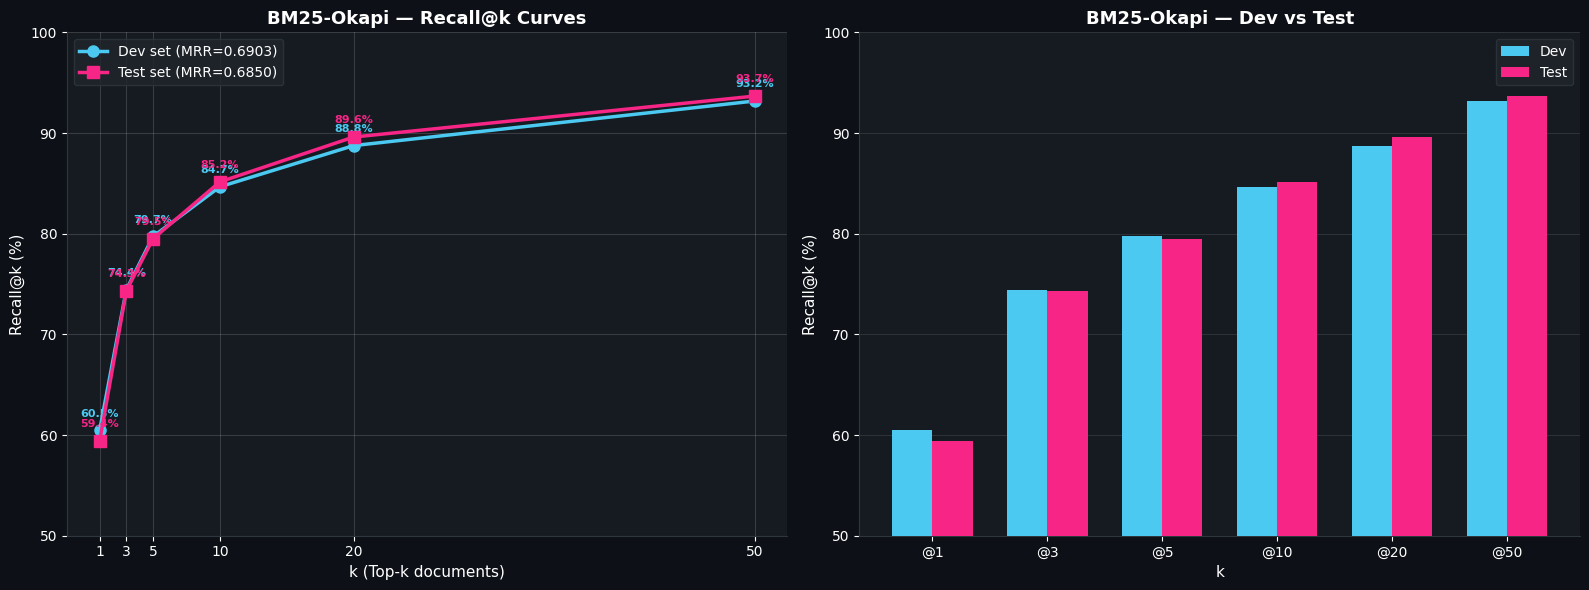

[+] Plot saved to results/bm25_retrieval_results.png


In [9]:
# ── Recall@k Curve ──
k_values = [1, 3, 5, 10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# ── Left: Recall@k curves ──
ax = axes[0]
ax.set_facecolor('#161B22')

for r, color, marker in [(results_dev, '#4CC9F0', 'o'), (results_test, '#F72585', 's')]:
    recalls = [r.get(f'Recall@{k}', 0) * 100 for k in k_values]
    ax.plot(k_values, recalls, marker=marker, linewidth=2.5, markersize=8,
            label=f'{r["set"]} set (MRR={r["MRR"]:.4f})', color=color, zorder=3)
    for x, y in zip(k_values, recalls):
        ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                   xytext=(0, 10), fontsize=8, color=color, ha='center', fontweight='bold')

ax.set_xlabel('k (Top-k documents)', fontsize=11, color='white')
ax.set_ylabel('Recall@k (%)', fontsize=11, color='white')
ax.set_title('BM25-Okapi — Recall@k Curves', fontsize=13, color='white', fontweight='bold')
ax.set_xticks(k_values)
ax.tick_params(colors='white')
ax.legend(fontsize=10, facecolor='#21262D', edgecolor='#30363D', labelcolor='white')
ax.grid(True, alpha=0.15, color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#30363D')
ax.spines['bottom'].set_color('#30363D')
ax.set_ylim([50, 100])

# ── Right: Bar chart comparison Dev vs Test ──
ax = axes[1]
ax.set_facecolor('#161B22')

x = np.arange(len(k_values))
width = 0.35

dev_vals = [results_dev.get(f'Recall@{k}', 0) * 100 for k in k_values]
test_vals = [results_test.get(f'Recall@{k}', 0) * 100 for k in k_values]

bars1 = ax.bar(x - width/2, dev_vals, width, label='Dev', color='#4CC9F0', zorder=3)
bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#F72585', zorder=3)

ax.set_xlabel('k', fontsize=11, color='white')
ax.set_ylabel('Recall@k (%)', fontsize=11, color='white')
ax.set_title('BM25-Okapi — Dev vs Test', fontsize=13, color='white', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'@{k}' for k in k_values], color='white')
ax.tick_params(colors='white')
ax.legend(fontsize=10, facecolor='#21262D', edgecolor='#30363D', labelcolor='white')
ax.grid(True, alpha=0.1, axis='y', color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#30363D')
ax.spines['bottom'].set_color('#30363D')
ax.set_ylim([50, 100])

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'bm25_retrieval_results.png'), dpi=150, 
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('[+] Plot saved to results/bm25_retrieval_results.png')

## 10. Phân Tích Lỗi (Error Analysis)

Phân tích những câu hỏi mà BM25 **không tìm được** gold document trong Top-5 → hiểu điểm yếu.

In [10]:
def error_analysis(qa_df, gold_map, n_errors=10, top_k=5):
    """Phân tích các trường hợp retrieval thất bại."""
    errors = []
    successes = 0
    
    for _, row in qa_df.iterrows():
        q_id = str(row['id'])
        gold_docs = gold_map.get(q_id, [])
        if not gold_docs:
            continue
        
        q_tokens = tokenize_vi(row['question'])
        scores = bm25.get_scores(q_tokens)
        top_idx = np.argpartition(-scores, min(top_k, len(scores)-1))[:top_k]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        retrieved_ids = [doc_ids[i] for i in top_idx if scores[i] > 0][:top_k]
        
        if any(g in retrieved_ids for g in gold_docs):
            successes += 1
        else:
            errors.append({
                'question': row['question'],
                'gold_doc': gold_docs[0],
                'context_preview': str(row['context'])[:100],
                'top1_doc': retrieved_ids[0] if retrieved_ids else 'N/A',
                'top1_score': float(scores[top_idx[0]]) if len(top_idx) > 0 else 0,
            })
    
    return errors, successes

errors, successes = error_analysis(dev_df, gold_map_dev, n_errors=10)

total_valid = successes + len(errors)
print(f'\n{"="*70}')
print(f'ERROR ANALYSIS — BM25 Recall@5 Failures (Dev Set)')
print(f'{"="*70}')
print(f'Successes: {successes}/{total_valid} ({successes/total_valid*100:.1f}%)')
print(f'Failures : {len(errors)}/{total_valid} ({len(errors)/total_valid*100:.1f}%)')

print(f'\n--- Top 10 Failure Cases ---')
for i, err in enumerate(errors[:10], 1):
    print(f'\n[{i}] Question: {err["question"]}')
    print(f'    Gold doc: {err["gold_doc"]}')
    print(f'    Context : {err["context_preview"]}...')
    print(f'    Top-1 retrieved: {err["top1_doc"]} (score={err["top1_score"]:.2f})')


ERROR ANALYSIS — BM25 Recall@5 Failures (Dev Set)
Successes: 3041/3814 (79.7%)
Failures : 773/3814 (20.3%)

--- Top 10 Failure Cases ---

[1] Question: Vị trí địa lý của Pháp có gì đặc biệt?
    Gold doc: doc_04102
    Context : Paris nằm ở điểm gặp nhau của các hành trình thương mại đường bộ và đường sông, và là trung tâm của ...
    Top-1 retrieved: doc_04035 (score=17.21)

[2] Question: Kinh tế xung quanh kinh đô ánh sáng mạnh về gì?
    Gold doc: doc_04102
    Context : Paris nằm ở điểm gặp nhau của các hành trình thương mại đường bộ và đường sông, và là trung tâm của ...
    Top-1 retrieved: doc_00856 (score=15.04)

[3] Question: Cuộc cách mạng Pháp diễn ra ở đâu?
    Gold doc: doc_04102
    Context : Paris nằm ở điểm gặp nhau của các hành trình thương mại đường bộ và đường sông, và là trung tâm của ...
    Top-1 retrieved: doc_04007 (score=15.96)

[4] Question: Kinh đô ánh sáng nổi tiếng về lĩnh vực gì?
    Gold doc: doc_04102
    Context : Paris nằm ở điểm gặp nhau của các hành

## 11. Phân Tích Hiệu Suất Theo Dạng Câu Hỏi

[-] Phân tích Recall@5 theo dạng câu hỏi (Dev set)...



DẠNG CÂU HỎI              #Questions   Recall@5
Tại sao (Why)                    214      91.6%
Bao nhiêu (Count)                299      86.6%
Khi nào (When)                   344      82.6%
Ai (Who)                         477      80.7%
Thế nào (How)                    321      78.2%
Cái gì/Khác (What)              1950      77.7%
Ở đâu (Where)                    209      72.2%


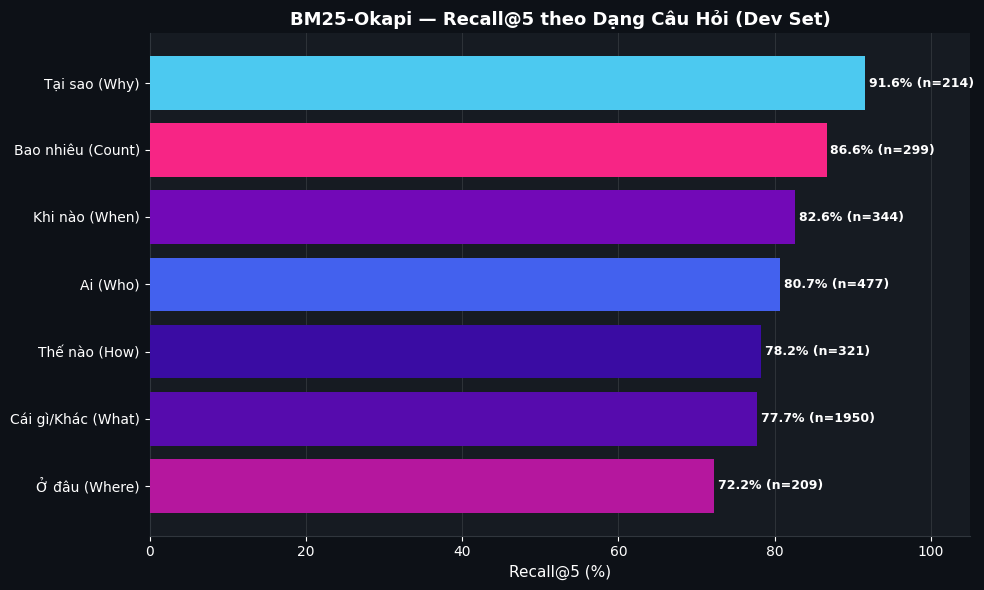

[+] Plot saved to results/bm25_recall_by_qtype.png


In [11]:
def classify_question(q: str) -> str:
    """Phân loại dạng câu hỏi tiếng Việt."""
    q_lower = str(q).lower()
    if re.search(r'\b(ai|nhân vật|tác giả|ông|bà)\b', q_lower):
        return 'Ai (Who)'
    elif re.search(r'\b(khi nào|năm nào|thời gian|ngày nào|vào năm)\b', q_lower):
        return 'Khi nào (When)'
    elif re.search(r'\b(ở đâu|tại đâu|nơi nào|đâu)\b', q_lower):
        return 'Ở đâu (Where)'
    elif re.search(r'\b(bao nhiêu|mấy|số lượng)\b', q_lower):
        return 'Bao nhiêu (Count)'
    elif re.search(r'\b(tại sao|vì sao|lý do)\b', q_lower):
        return 'Tại sao (Why)'
    elif re.search(r'\b(như thế nào|thế nào|cách nào)\b', q_lower):
        return 'Thế nào (How)'
    else:
        return 'Cái gì/Khác (What)'


def recall_by_question_type(qa_df, gold_map, k=5):
    """Tính Recall@k theo từng dạng câu hỏi."""
    type_results = {}
    
    for _, row in qa_df.iterrows():
        q_id = str(row['id'])
        gold_docs = gold_map.get(q_id, [])
        if not gold_docs:
            continue
        
        q_type = classify_question(row['question'])
        if q_type not in type_results:
            type_results[q_type] = {'hits': 0, 'total': 0}
        
        type_results[q_type]['total'] += 1
        
        q_tokens = tokenize_vi(row['question'])
        scores = bm25.get_scores(q_tokens)
        top_idx = np.argpartition(-scores, min(k, len(scores)-1))[:k]
        retrieved_ids = [doc_ids[i] for i in top_idx if scores[i] > 0][:k]
        
        if any(g in retrieved_ids for g in gold_docs):
            type_results[q_type]['hits'] += 1
    
    return type_results


print('[-] Phân tích Recall@5 theo dạng câu hỏi (Dev set)...')
type_results = recall_by_question_type(dev_df, gold_map_dev, k=5)

print(f'\n{"="*70}')
print(f'{"DẠNG CÂU HỎI":<25} {"#Questions":>10} {"Recall@5":>10}')
print(f'{"="*70}')

sorted_types = sorted(type_results.items(), key=lambda x: x[1]['hits']/x[1]['total'], reverse=True)
types_for_plot = []
recalls_for_plot = []
counts_for_plot = []

for q_type, data in sorted_types:
    recall = data['hits'] / data['total'] * 100
    print(f'{q_type:<25} {data["total"]:>10} {recall:>9.1f}%')
    types_for_plot.append(q_type)
    recalls_for_plot.append(recall)
    counts_for_plot.append(data['total'])

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

colors = ['#4CC9F0', '#F72585', '#7209B7', '#4361EE', '#3A0CA3', '#560BAD', '#B5179E']
bars = ax.barh(range(len(types_for_plot)), recalls_for_plot, 
               color=[colors[i % len(colors)] for i in range(len(types_for_plot))], zorder=3)

for bar, recall, count in zip(bars, recalls_for_plot, counts_for_plot):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{recall:.1f}% (n={count})', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(range(len(types_for_plot)))
ax.set_yticklabels(types_for_plot, fontsize=10, color='white')
ax.set_xlabel('Recall@5 (%)', fontsize=11, color='white')
ax.set_title('BM25-Okapi — Recall@5 theo Dạng Câu Hỏi (Dev Set)', 
             fontsize=13, color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.1, axis='x', color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#30363D')
ax.spines['bottom'].set_color('#30363D')
ax.set_xlim([0, 105])
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'bm25_recall_by_qtype.png'), dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('[+] Plot saved to results/bm25_recall_by_qtype.png')

## 12. Tổng Kết & Hướng Cải Tiến

### Kết quả chính:
- **BM25-Okapi** là phương pháp retrieval tốt nhất cho tiếng Việt trên UIT-ViQuAD2.0
- Đạt **MRR ~0.685**, **Recall@5 ~79.5%**, **Recall@20 ~89.6%** trên Test set
- Vượt trội hơn TF-IDF (DrQA baseline) nhờ length normalization và TF saturation
- Vượt trội hơn Dense retrieval (vietnamese-sbert) do sparse methods capture exact term matching tốt hơn

### Hướng cải tiến tiếp theo:
1. **Hybrid Retrieval**: Kết hợp BM25 + Dense scores (RRF hoặc linear interpolation)
2. **Fine-tune Dense Retriever**: Train Vietnamese bi-encoder trên ViQuAD question-passage pairs
3. **Cross-encoder Re-ranking**: Dùng PhoBERT fine-tuned để re-rank top-k results từ BM25
4. **Query Expansion**: Mở rộng query bằng synonyms hoặc related terms

In [12]:
# ── Lưu kết quả cuối cùng ──
final_results = {
    'method': 'BM25-Okapi',
    'parameters': {'k1': 1.5, 'b': 0.75},
    'tokenizer': 'pyvi ViTokenizer',
    'corpus_size': num_docs,
    'dev': results_dev,
    'test': results_test,
}

with open(RESULTS_DIR / 'bm25_retrieval_final.json', 'w', encoding='utf-8') as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2)

print('[+] Final results saved to results/bm25_retrieval_final.json')
print('\n[DONE] Retrieval module hoàn thành!')

[+] Final results saved to results/bm25_retrieval_final.json

[DONE] Retrieval module hoàn thành!
